<a href="https://colab.research.google.com/github/vennelanalajam/myproject/blob/main/Earthquakeprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title : Earthquake Damage Prediction

#Step 1 :  Problem Statement
Earthquake Damage Prediction

# Objective
The goal of this project is to predict the level of damage (damage_grade) caused to buildings during an earthquake.

## Target Variable
damage_grade:
- 1 → Low damage
- 2 → Medium damage
- 3 → High damage (Destruction)

## Tasks
1. Perform Exploratory Data Analysis (EDA)
2. Build Machine Learning models
3. Compare models and select the best one
4. Provide actionable suggestions to reduce damage


# Step 2 : Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Step 3 : Load Datasets

In [3]:
train_values = pd.read_csv("/content/train_values.csv")
test_values = pd.read_csv("/content/train_labels.csv")

df = train_values.merge(test_values, on = "building_id")
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3


# Step 4 : Basic Data Understanding
# Dataset Overview
- Number of rows and columns
- Data types
- Missing values

In [4]:
df.shape

(260601, 40)

In [5]:
df.dtypes

,0
building_id,int64
geo_level_1_id,int64
geo_level_2_id,int64
geo_level_3_id,int64
count_floors_pre_eq,int64
age,int64
area_percentage,int64
height_percentage,int64
land_surface_condition,object
foundation_type,object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [7]:
df.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,0.034332,0.018235,0.068154,0.075268,0.254988,0.085011,0.042590,0.015859,0.014985,0.983949,0.111880,0.064378,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,0.182081,0.133800,0.252010,0.263824,0.435855,0.278899,0.201931,0.124932,0.121491,0.418389,0.315219,0.245426,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


In [8]:
df.isnull().sum()

,0
building_id,0
geo_level_1_id,0
geo_level_2_id,0
geo_level_3_id,0
count_floors_pre_eq,0
age,0
area_percentage,0
height_percentage,0
land_surface_condition,0
foundation_type,0


In [9]:
df.duplicated().sum()

np.int64(0)

# Step 5 : Data Preprocessing
# Data Cleaning Steps
- No missing values
- Drop unnecessary columns
- Handle categorical features

In [10]:
# drop id columns
df.drop("building_id", axis = 1, inplace = True)

In [11]:
df.columns

Index(['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_industry',
     

# Encoding categorical Variables

# Encoding Strategy
- Label Encoding for categorical columns


In [12]:
# Encoding Categorical Variables
cat_cols = df.select_dtypes(include = ["object"]).columns

le = LabelEncoder()
for col in cat_cols:
  df[col] = le.fit_transform(df[col])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   geo_level_1_id                          260601 non-null  int64
 1   geo_level_2_id                          260601 non-null  int64
 2   geo_level_3_id                          260601 non-null  int64
 3   count_floors_pre_eq                     260601 non-null  int64
 4   age                                     260601 non-null  int64
 5   area_percentage                         260601 non-null  int64
 6   height_percentage                       260601 non-null  int64
 7   land_surface_condition                  260601 non-null  int64
 8   foundation_type                         260601 non-null  int64
 9   roof_type                               260601 non-null  int64
 10  ground_floor_type                       260601 non-null  int64
 11  

# Step 6 : Exploratory Data Analysis(EDA)


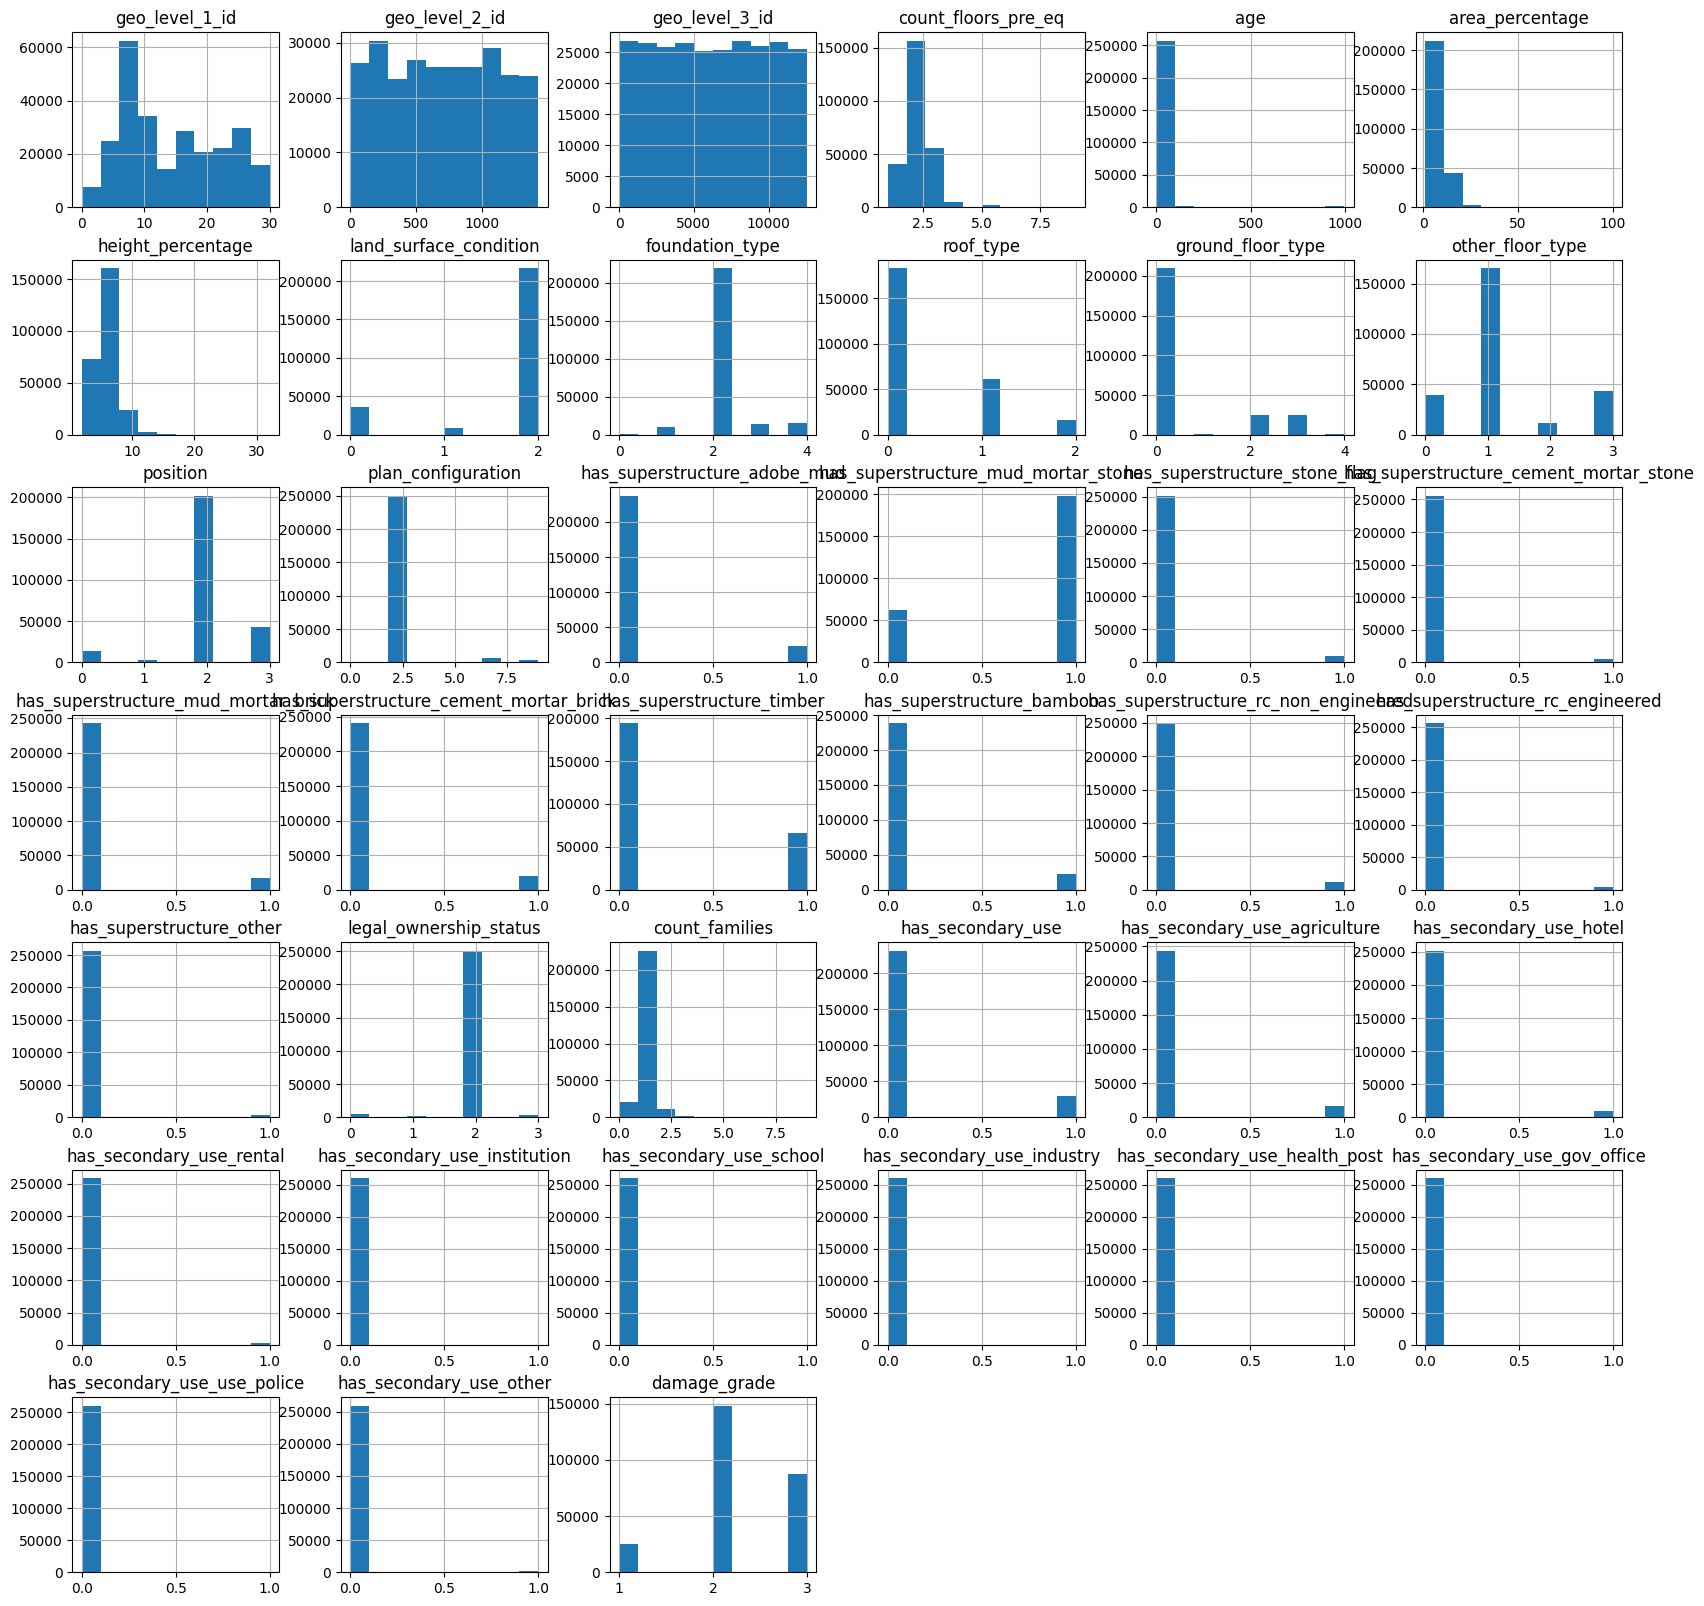

In [17]:
# Univariate Analysis
df.hist(figsize=(20,20))
plt.show()

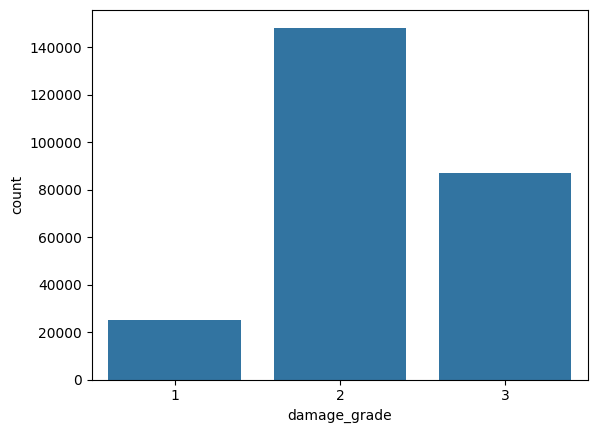

In [18]:
# Target Distribution
sns.countplot(x = "damage_grade",data = df)
plt.show()

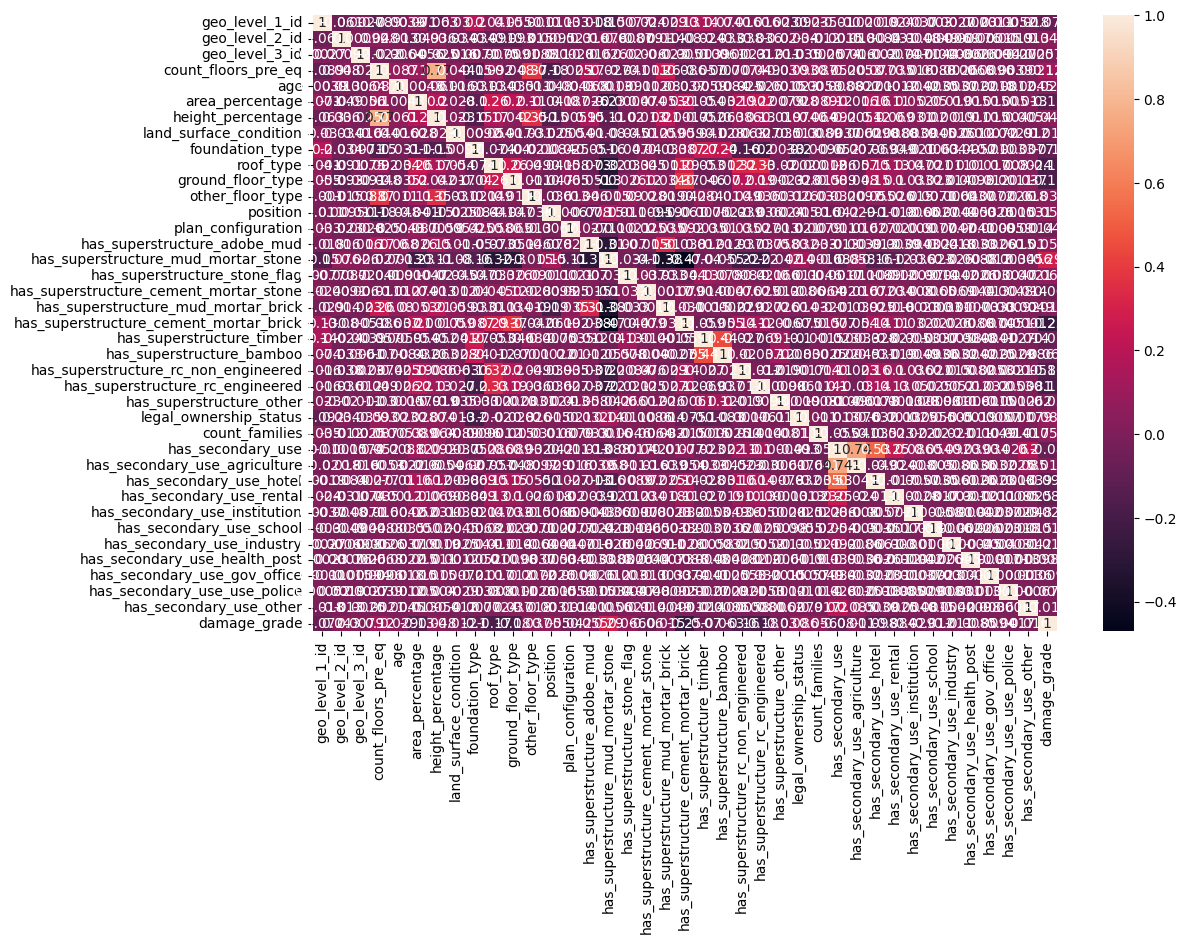

In [21]:
# correlation Analysis
plt.figure(figsize = (12,8))
sns.heatmap(df.corr(), annot = True)
plt.show()

# Outliers Handling
## Outlier Strategy
- Tree-based models are robust to outliers
- Since dataset has minimal outliers → NO removal required

# Step 7 : Train-Test Split

In [28]:
x = df.drop("damage_grade", axis = 1)
y = df["damage_grade"]
x_train,x_test , y_train , y_test = train_test_split(x,y, test_size = 0.2,random_state =  42)

# Step 8 : Model Building

# Decision Tree

In [34]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

# Random Forest

In [35]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

# Logistic Regression

In [36]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train , y_train)

y_pred_lr = lr.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Gradient Boosting

In [37]:
gb = GradientBoostingClassifier()
gb.fit(x_train,y_train)
y_pred_gb = gb.predict(x_test)

# Step 9 : Model_Evaluation
## Evaluation Metrics
- Accuracy
- Confusion Matrix
- Classification Report

In [38]:
def evaluate(y_test, y_pred , model_name):
  print(f"Model : {model_name}")
  print("Accuracy:", accuracy_score(y_test, y_pred))
  print(classification_report(y_test, y_pred))
  print(confusion_matrix(y_test, y_pred))
  print("-"*50)

evaluate(y_test ,y_pred_dt , "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_lr, "Logistic Regreesion")
evaluate(y_test, y_pred_gb, "Gradient Boosting")

Model : Decision Tree
Accuracy: 0.6566834865025614
              precision    recall  f1-score   support

           1       0.49      0.50      0.50      5170
           2       0.71      0.71      0.71     29487
           3       0.62      0.62      0.62     17464

    accuracy                           0.66     52121
   macro avg       0.61      0.61      0.61     52121
weighted avg       0.66      0.66      0.66     52121

[[ 2591  2249   330]
 [ 2312 20792  6383]
 [  367  6253 10844]]
--------------------------------------------------
Model : Random Forest
Accuracy: 0.7205349091537
              precision    recall  f1-score   support

           1       0.67      0.48      0.56      5170
           2       0.72      0.83      0.77     29487
           3       0.72      0.61      0.66     17464

    accuracy                           0.72     52121
   macro avg       0.71      0.64      0.67     52121
weighted avg       0.72      0.72      0.71     52121

[[ 2499  2577    94]
 [ 

# Step 10 : Model Comparision Report
## Model Comparison

| Model               | Accuracy | Performance |
|--------------------|---------|------------|
| Decision Tree      | Medium  | Overfitting |
| Random Forest      | High    | Best Model |
| Logistic Regression| Low     | Underfitting |
| Gradient Boosting  | High    | Competitive |

## Final Choice
✅ Random Forest is selected for production because:
- Handles categorical + numerical well
- Robust to outliers
- High accuracy

# Step 13 : Challenges Faced
## Challenges

- Categorical features with encoded labels (not meaningful)
- High number of features (39 columns)
- Feature correlation complexity
- Class imbalance in damage_grade
- No domain meaning for encoded categories

# Step 14: Suggestions to Seismologists
## Key Insights & Suggestions

- Older buildings → higher damage → reinforce aging structures
- Mud/stone materials → high damage → use reinforced concrete
- More floors → more risk → limit vertical expansion
- Poor land conditions → more damage → improve soil stability
- Non-engineered buildings → highest risk → enforce regulations

## Final Advice
Focus on:
- Structural engineering quality
- Material improvement
- Seismic-resistant design

# Step 15 : Final Conclusion
## Conclusion

- Built a classification model to predict earthquake damage
- Random Forest performed best
- Identified key structural risk factors
- Provided actionable real-world recommendations